In [5]:
from Config import *
from main import *
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
%matplotlib inline



Fitting 3 folds for each of 27 candidates, totalling 81 fits
Найкращий ROC-AUC: 0.8427
Найкращі параметри: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

====== РЕЗУЛЬТАТИ ФІНАЛЬНОГО ПАЙПЛАЙНУ ======
ROC-AUC на валідації: 0.8568
Accuracy на валідації: 0.7424


In [6]:
raw_dt = pd.read_csv(RAW_DATA_PATH)
raw_dt.head(5)

raw_dt = raw_dt.replace(r'^\s*$', np.nan, regex=True)
raw_dt['TotalCharges'] = raw_dt['TotalCharges'].fillna(0)

raw_dt['TotalCharges'] = pd.to_numeric(raw_dt['TotalCharges'],errors='coerce')
no_churn




3635

In [5]:
def check_data(dataframe, head=5):

    print(20*"-" + "Information".center(20) + 20*"-")
    print(dataframe.info())
    print(20*"-" + "Data Shape".center(20) + 20*"-")
    print(dataframe.shape)
    print("\n" + 20*"-" + "The First 5 Data".center(20) + 20*"-")
    print(dataframe.head(head))
    print("\n" + 20 * "-" + "The Last 5 Data".center(20) + 20 * "-")
    print(dataframe.tail(head))
    print("\n" + 20 * "-" + "Missing Values".center(20) + 20 * "-")
    print(dataframe.isnull().sum())
    print("\n" + 40 * "-" + "Describe the Data".center(40) + 40 * "-")
    print(dataframe.describe([0.01, 0.05, 0.10, 0.50, 0.75, 0.90, 0.95, 0.99]).T)


check_data(raw_dt)

--------------------    Information     --------------------
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str  

In [7]:
churn_unigue_values = raw_dt['Churn'].unique()
raw_dt['Churn'] = raw_dt['Churn'].map({churn_unigue_values[0] : 0,churn_unigue_values[1] : 1})
list(raw_dt['Churn'].value_counts())

[5174, 1869]

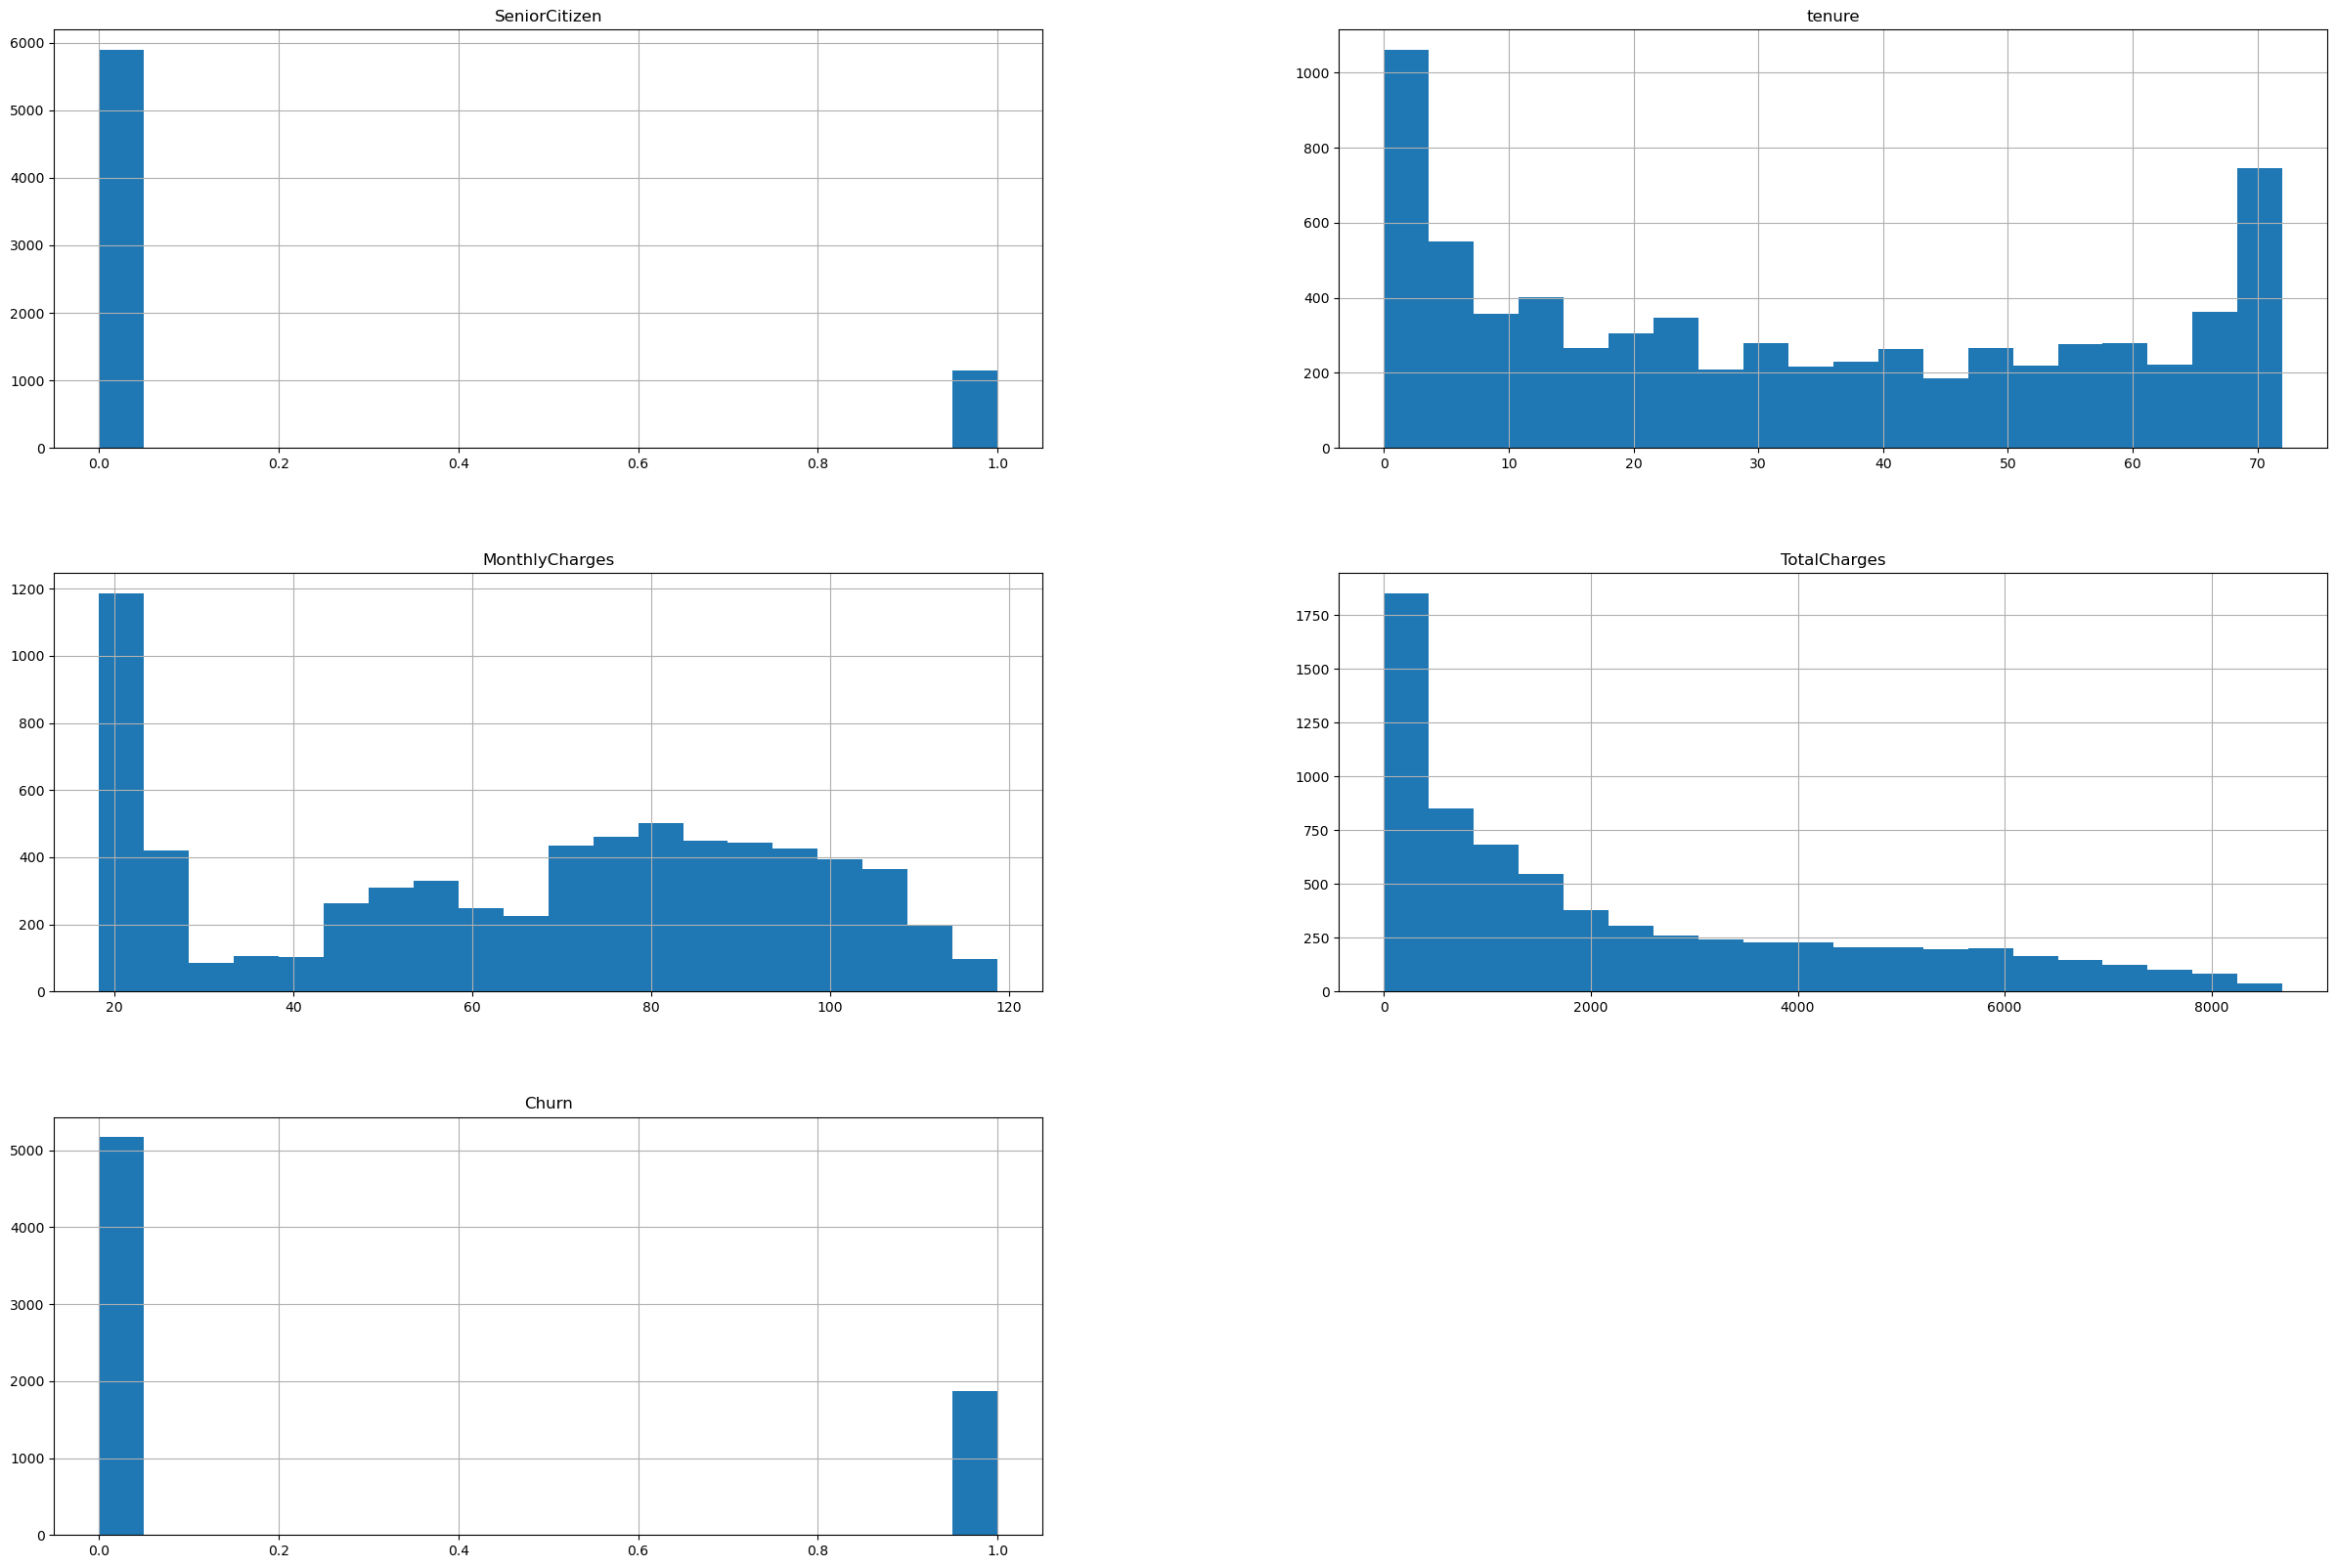

In [7]:
num_bins = 20
raw_dt.hist(bins=num_bins, figsize=(30,20))
DATA_ANALISYS_DATA.mkdir(parents=True, exist_ok=True)
plt.savefig(DATA_ANALISYS_DATA / 'churn_histogram.png')
plt.show()
plt.close()


In [18]:
def grab_col_names(dataframe, cat_th=10, car_th=20) -> tuple: # returns [categorical_colums, numerical_columns, categorical_highy_cordinality_columns]
  
    # cat_cols, cat_but_car
    raw_cat_cols = dataframe.select_dtypes(include=['category']).columns.tolist()
    raw_num_cols = dataframe.select_dtypes(include=['number']).columns.tolist()
    
    # 2. Шукаємо числа, які є категоріями (наприклад, SeniorCitizen: 0 або 1)
    num_but_cat = [col for col in raw_num_cols if dataframe[col].nunique() < cat_th]
    
    # 3. Шукаємо тексти з величезною кардинальністю (якщо закрався якийсь ID)
    cat_but_car = [col for col in raw_cat_cols if dataframe[col].nunique() > car_th]
    
    # 4. Формуємо фінальний список КАТЕГОРІАЛЬНИХ колонок
    # Додаємо числові категорії та викидаємо висококардинальний текст
    cat_cols = raw_cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]
    
    # 5. Формуємо фінальний список ЧИСЛОВИХ колонок
    # Просто прибираємо з усіх чисел ті, які ми визнали категоріями
    num_cols = [col for col in raw_num_cols if col not in num_but_cat]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(raw_dt)



Observations: 7043
Variables: 21
cat_cols: 2
num_cols: 3
cat_but_car: 0
num_but_cat: 2


In [13]:
num_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

In [12]:
for col_name in cat_cols:
    print(f'{col_name} unique values : {raw_dt[col_name].unique()}')

gender unique values : <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner unique values : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents unique values : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService unique values : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines unique values : <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService unique values : <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity unique values : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup unique values : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection unique values : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport unique values : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV unique values : <StringArray>
['No', 'Yes', 'No internet service']
Len

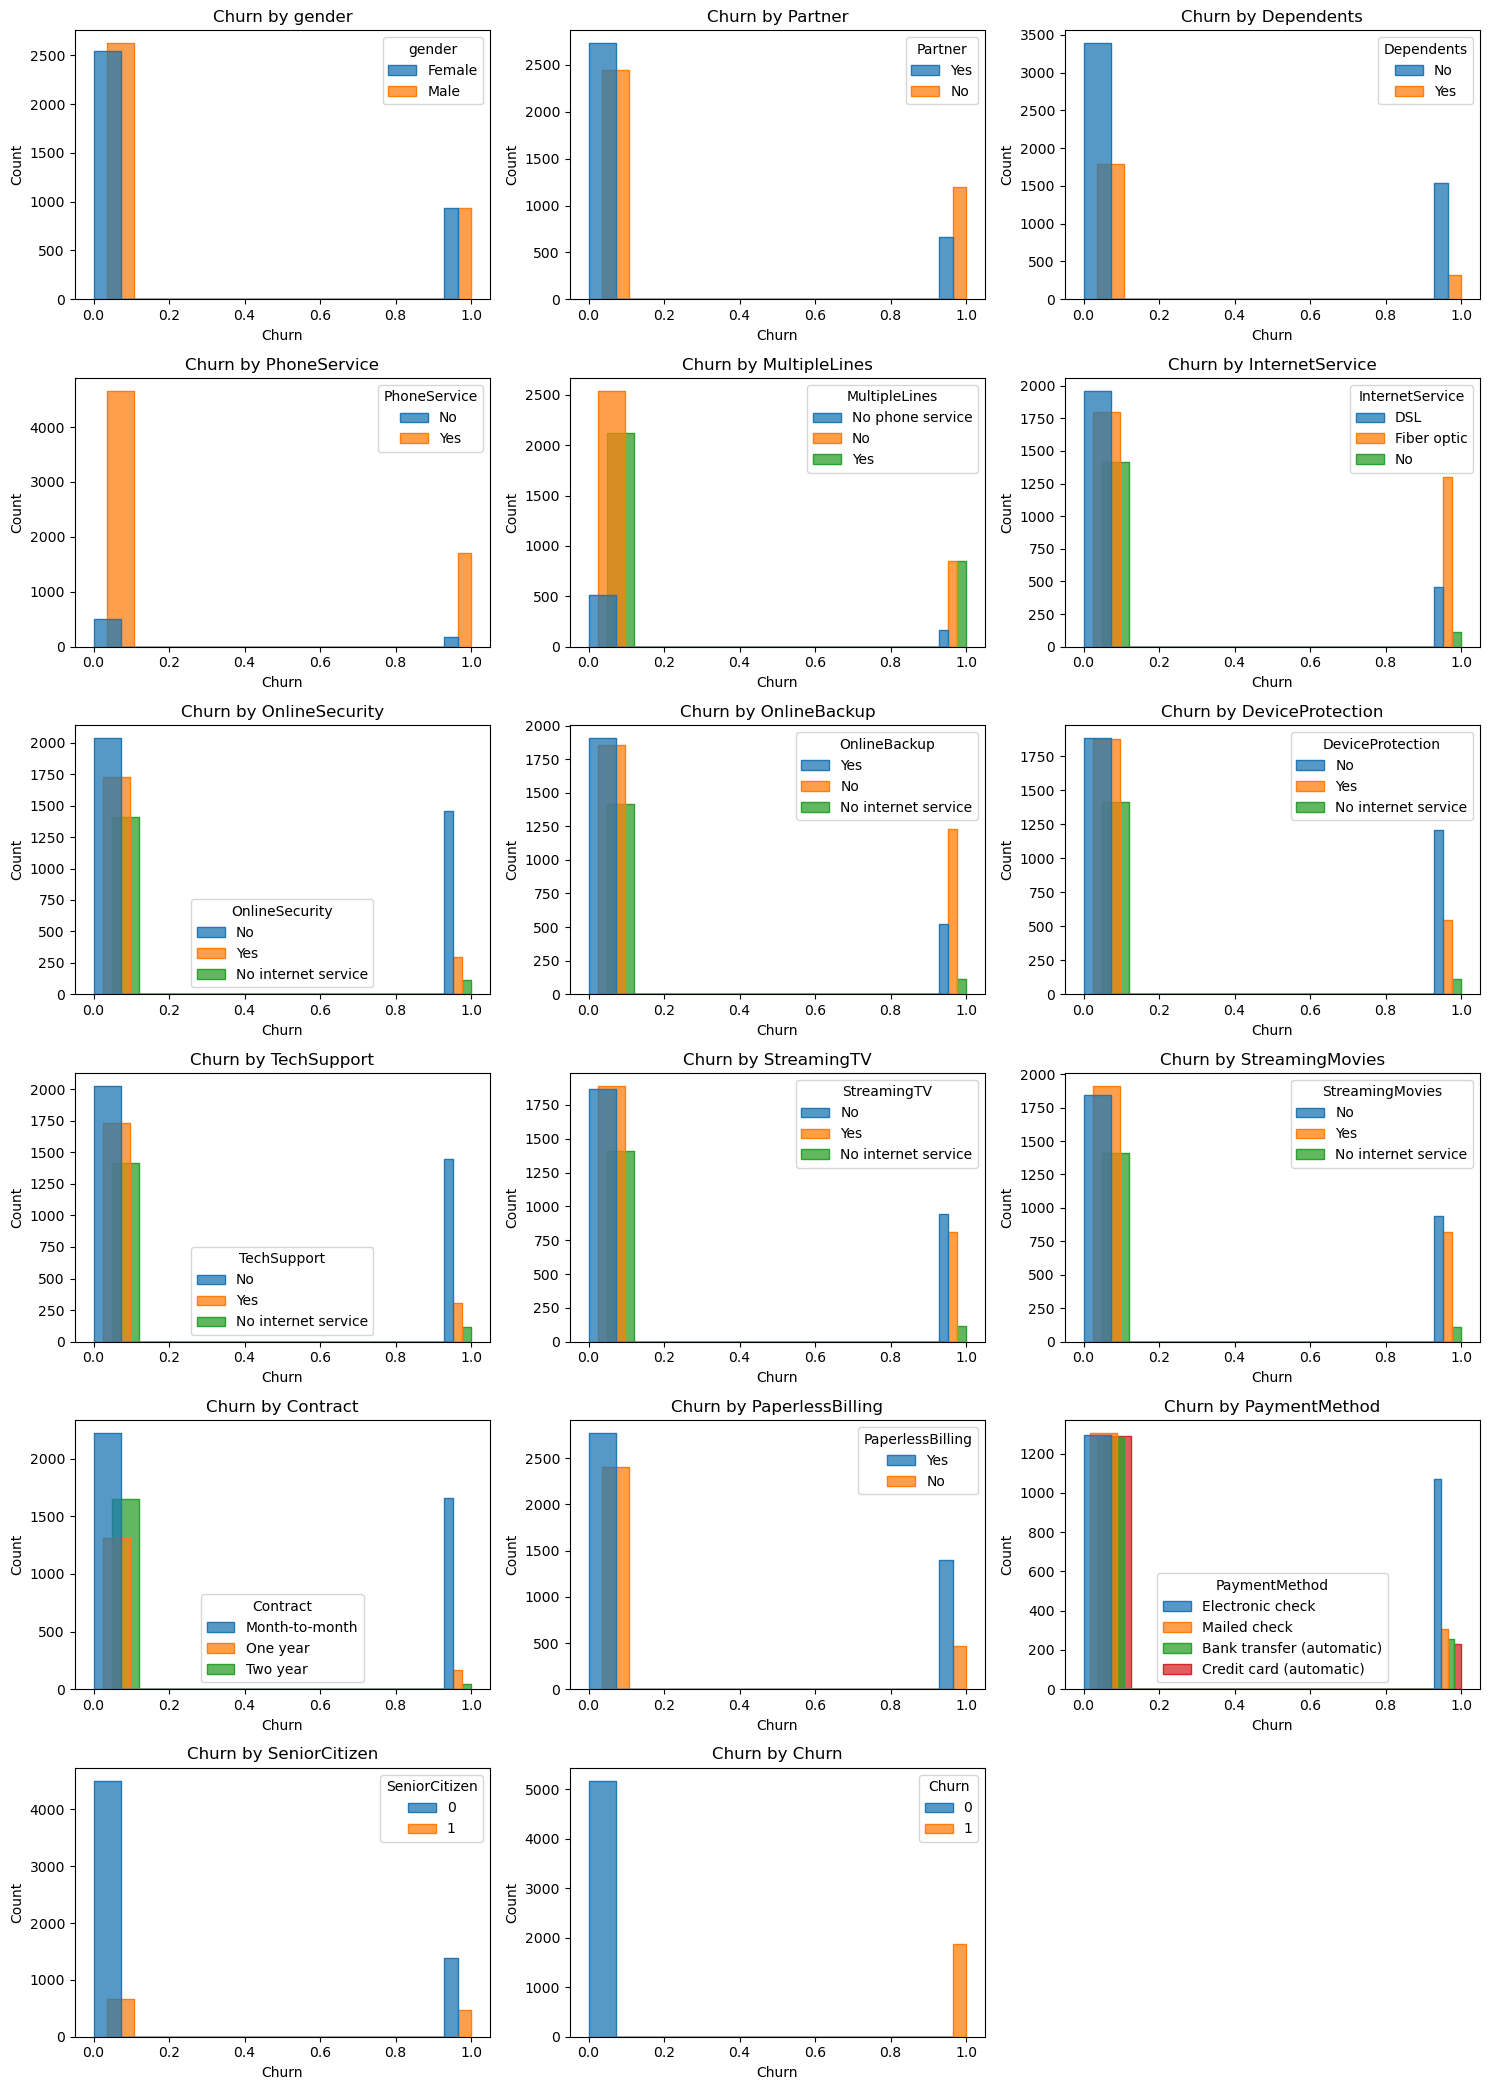

In [ ]:

def target_vs_category_grid(dataframe, target, categorical_cols,save_dir):
    # 1. Calculate grid dimensions dynamically (3 columns per row)
    num_plots = len(categorical_cols)
    cols = 3
    rows = ceil(num_plots / cols)

    # 2. Automatically scale overall figure size based on rows/cols
    # Each individual plot gets roughly 5 inches width, 3.5 inches height
    fig, axs = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))

    # 3. Flatten the axes array for easy left-to-right looping
    axs_flat = axs.flatten() if num_plots > 1 else [axs]

    # 4. Loop through features and plot sequentially
    for i, col in enumerate(categorical_cols):
        ax = axs_flat[i]
        sns.histplot(
            x=target,
            hue=col,
            data=dataframe,
            element="step",
            multiple="dodge",
            ax=ax,  # <--- Crucial: draws on the specific subplot
        )
        ax.set_title(f"Churn by {col}")

    # 5. Delete any unused, blank axes at the end of the grid
    for j in range(i + 1, len(axs_flat)):
        fig.delaxes(axs_flat[j])

    # 6. Fix overlap and show the single combined picture
    plt.tight_layout()
    plt.savefig(save_dir / 'categorical_to_target_histplot.png')
    plt.show()
    plt.close()


# Call the function once with your list of columns
target_vs_category_grid(raw_dt, "Churn", cat_cols, DATA_ANALISYS_DATA)


In [ ]:
def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n")

for col in num_cols:
    target_summary_with_num(raw_dt, "Churn", col)


          tenure
Churn           
0      37.569965
1      17.979133

       MonthlyCharges
Churn                
0           61.265124
1           74.441332

       TotalCharges
Churn              
0       2549.911442
1       1531.796094



In [ ]:
def target_summary_with_cat(dataframe,target,categorical_col):
    print(dataframe.groupby(categorical_col)[target].mean())
    print('\n')
    #print(pd.DataFrame({"CHURN_MEAN": dataframe.groupby(categorical_col)[target].mean()}))


for col in cat_cols:
    target_summary_with_cat(raw_dt, "Churn", col)

gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64


Partner
No     0.329580
Yes    0.196649
Name: Churn, dtype: float64


Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64


PhoneService
No     0.249267
Yes    0.267096
Name: Churn, dtype: float64


MultipleLines
No                  0.250442
No phone service    0.249267
Yes                 0.286099
Name: Churn, dtype: float64


InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64


OnlineSecurity
No                     0.417667
No internet service    0.074050
Yes                    0.146112
Name: Churn, dtype: float64


OnlineBackup
No                     0.399288
No internet service    0.074050
Yes                    0.215315
Name: Churn, dtype: float64


DeviceProtection
No                     0.391276
No internet service    0.074050
Yes                    0.225021
Name: Churn, dtype: float64


TechSupport
No                     

In [ ]:
def outlier_thresholds(dataframe, col_name, q1=0.25, q3=0.75):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

def grab_outliers(dataframe, col_name, index=False):
    low, up = outlier_thresholds(dataframe, col_name)

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

for col in num_cols:
    print(col, check_outlier(raw_dt, col))

tenure False
MonthlyCharges False
TotalCharges False


In [ ]:
corr_matrix = raw_dt[num_cols].corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


In [ ]:
raw_dt[num_cols].corrwith(raw_dt["Churn"]).sort_values(ascending=False)


MonthlyCharges    0.193356
TotalCharges     -0.198324
tenure           -0.352229
dtype: float64

In [ ]:
transformed_df.head()

,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender,cat__Partner,cat__Dependents,cat__PhoneService,cat__MultipleLines,cat__InternetService,cat__OnlineSecurity,cat__OnlineBackup,cat__DeviceProtection,cat__TechSupport,cat__StreamingTV,cat__StreamingMovies,cat__Contract,cat__PaperlessBilling,cat__PaymentMethod,cat__SeniorCitizen
0,0.881078,0.195927,0.653404,1.0,1.0,1.0,1.0,2.0,0.0,0.0,2.0,0.0,2.0,2.0,0.0,1.0,1.0,2.0,0.0
1,-1.284263,0.522755,-0.976492,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,2.0,0.0
2,-0.793997,-1.509551,-0.897371,1.0,0.0,0.0,1.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0
3,-0.344587,1.053643,-0.012148,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0,0.0,2.0,2.0,2.0,1.0,2.0,1.0
4,-1.079985,0.308740,-0.812882,0.0,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
